# Verification

**INPUT**: Preprocessed train, validation, test corpora

**OUTPUT**: Preprocessing validation, tokenizer parameter decisions

| Step | Decision | Status | Comment |
|------|----------|--------|---------|
| Preprocessing impact | Evaluate cleaning | Done | Message length distribution (only on train), removed messages |
| Class distribution | Detect imbalance | Done | Compare train/val/test |
| Vocabulary size estimation | Model complexity | Done | Unique tokens in train, rare tokens? |

## Input & Setup

### Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import Counter
import sys
from pathlib import Path

project_root = Path().resolve().parent
src = project_root / "src"
if str(src) not in sys.path:
    sys.path.insert(0, str(src))

from config.config import PATHS

### Read corpora

In [2]:
corpus = pd.read_csv(PATHS.corpus_raw)
train = pd.read_csv(PATHS.train_processed)
validation = pd.read_csv(PATHS.validation_processed)
test = pd.read_csv(PATHS.test_processed)

## Steps

### Preprocessing impact

#### Message length distribution

In [3]:
msg_lengths = train["Message"].str.len()
char_length_statistics = msg_lengths.describe()

spam_msg_lengths = train[train['Spam/Ham'] == 'spam']['Message'].str.len()
spam_char_lengths_statistics = spam_msg_lengths.describe()

ham_msg_lengths = train[train['Spam/Ham'] == 'ham']['Message'].str.len()
ham_char_lengths_statistics = ham_msg_lengths.describe()


def print_length_statistics(column):
    statistics = column.str.len().describe()
    for stat, value in statistics.items():
        print(f"{stat+':':<10} {value:>8.2f}")

print_length_statistics(train["Message"])

count:     17387.00
mean:        844.98
std:         726.25
min:           8.00
25%:         307.00
50%:         592.00
75%:        1165.00
max:        3618.00


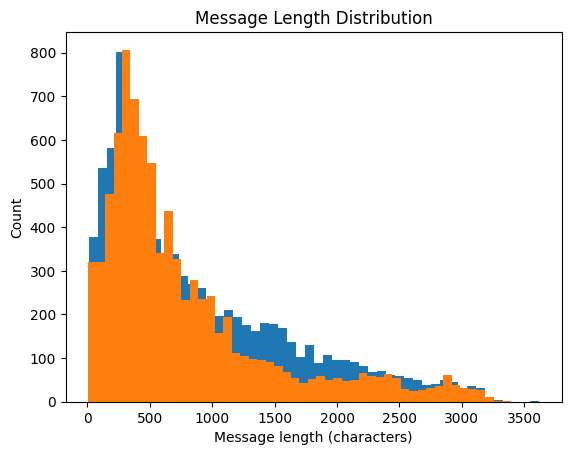

In [8]:
plt.figure()
plt.hist(ham_msg_lengths, bins=50)
plt.hist(spam_msg_lengths, bins=50)
plt.xlabel("Message length (characters)")
plt.ylabel("Count")
plt.title("Message Length Distribution")
plt.savefig("outlier_removed_charachter_message_length_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

#### Removed messages

In [5]:
num_of_original_entries = len(corpus)
num_of_new_entries = len(train) + len(validation) + len(test)
num_of_removed_entries = num_of_original_entries - num_of_new_entries

print(f"Original number of entries: {num_of_original_entries}")
print(f"New number of entries: {num_of_new_entries}")
print(f"Number of removed entries: {num_of_removed_entries}")

Original number of entries: 33716
New number of entries: 29405
Number of removed entries: 4311


### Check Class distribution

In [6]:
def class_distribution(name, corpus, label_column):
    num_of_labels = corpus[label_column].value_counts().to_dict()
    percentage_of_labels = {key:round(value/len(corpus)*100, 2) for key,value in num_of_labels.items()}
    print(f"Class distribution for {label_column} in {name}:")
    print(f"Number of labels:")
    for label, count in num_of_labels.items():
        print(f"{label.capitalize()}: {count}")
    
    print(f"Percentage of labels:")
    for label, percentage in percentage_of_labels.items():
        print(f"{label.capitalize()}: {percentage} %")
    print("\n")

class_distribution("train corpus", train, "Spam/Ham")
class_distribution("validation corpus", validation, "Spam/Ham")
class_distribution("test corpus", test, "Spam/Ham")

Class distribution for Spam/Ham in train corpus:
Number of labels:
Ham: 8842
Spam: 8545
Percentage of labels:
Ham: 50.85 %
Spam: 49.15 %


Class distribution for Spam/Ham in validation corpus:
Number of labels:
Spam: 3007
Ham: 2968
Percentage of labels:
Spam: 50.33 %
Ham: 49.67 %


Class distribution for Spam/Ham in test corpus:
Number of labels:
Spam: 3028
Ham: 3015
Percentage of labels:
Spam: 50.11 %
Ham: 49.89 %




### Vocabulary size estimation

In [7]:
messages = train['Message'].astype(str)
tokens = messages.apply(lambda x: re.findall(r"[a-z0-9]+", x))
vocab = {token for msg in tokens for token in msg}
vocab_size = len(vocab)
print("Estimated vocabulary size:", vocab_size)

all_tokens = [token for msg in tokens for token in msg]
token_counts = Counter(all_tokens)
rare_threshold = 3
rare_tokens = [t for t, c in token_counts.items() if c < rare_threshold]
print(f"Number of rare tokens (frequency < {rare_threshold}):", len(rare_tokens))
print("Percentage of rare tokens: {:.2%}".format(len(rare_tokens)/vocab_size))
print(vocab_size-len(rare_tokens), "tokens occur at least", rare_threshold, "times")

Estimated vocabulary size: 82789
Number of rare tokens (frequency < 3): 51717
Percentage of rare tokens: 62.47%
31072 tokens occur at least 3 times
